# Scraping Terrenos — Processed to Gold

Transforma `data/processed/scraping_manual/scraping_land_processed.csv` en el gold dataset `data/gold/final_land_scraping.csv` listo para modelado ML.

**Pipeline:**
1. Carga del dataset
2. Filtrado de categorías de suelo con pocos registros
3. Eliminación de outliers (IQR×1.5 sobre log del precio)
4. Exclusión de features con data leakage
5. Log-transformación del target (`log_precio`)
6. Target encoding de `municipio`
7. One-hot encoding de `tipo_suelo`
8. Conversión de booleanos a enteros
9. Exportación al gold layer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

## 1. Carga del dataset

In [2]:
df = pd.read_csv('../../data/processed/scraping_manual/scraping_land_processed.csv', sep=';')

print(f'Shape inicial: {df.shape}')
df.head(3)

Shape inicial: (828, 8)


,titulo,municipio,precio_eur,superficie_m2,tipo_suelo,vendido_con_descuento,es_urbano_o_urbanizable,precio_m2
0,"Oruña, Piélagos",Piélagos,139000,965.0,Urbano (solar),False,True,144.041451
1,"Peñacastillo - Nuevamontaña, Santander",Santander,169000,650.0,Urbano (solar),False,True,260.000000
2,"Calle Barrio San Roque, Polanco",Polanco,80000,1668.0,Urbano (solar),False,True,47.961631


In [3]:
print('Tipos de dato:')
print(df.dtypes)
print()
print('Nulos:')
print(df.isnull().sum())

Tipos de dato:
titulo                      object
municipio                   object
precio_eur                   int64
superficie_m2              float64
tipo_suelo                  object
vendido_con_descuento         bool
es_urbano_o_urbanizable       bool
precio_m2                  float64
dtype: object

Nulos:
titulo                     0
municipio                  0
precio_eur                 0
superficie_m2              0
tipo_suelo                 0
vendido_con_descuento      0
es_urbano_o_urbanizable    0
precio_m2                  0
dtype: int64


## 2. Filtrado de categorías de suelo con pocos registros

Se analiza la distribución de `tipo_suelo` para identificar categorías con muestra insuficiente para modelar.

Registros por categoría de suelo:
tipo_suelo
Urbano (solar)    452
Urbanizable       239
No urbanizable    133
Industrial          4
Name: count, dtype: int64


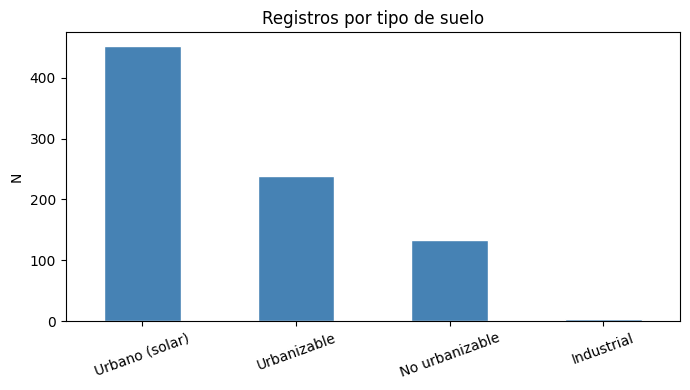

In [4]:
conteo_tipo_suelo = df['tipo_suelo'].value_counts()
print('Registros por categoría de suelo:')
print(conteo_tipo_suelo)

fig, ax = plt.subplots(figsize=(7, 4))
conteo_tipo_suelo.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Registros por tipo de suelo')
ax.set_xlabel('')
ax.set_ylabel('N')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [5]:
# Solo 'Industrial' tiene registros insuficientes (4 observaciones).
# 'No urbanizable' tiene 133 registros — muestra adecuada, se conserva.
# Umbral: se eliminan categorías con menos de 10 registros.

UMBRAL_MIN = 10
categorias_validas = conteo_tipo_suelo[conteo_tipo_suelo >= UMBRAL_MIN].index.tolist()
categorias_eliminadas = conteo_tipo_suelo[conteo_tipo_suelo < UMBRAL_MIN].index.tolist()

print(f'Categorías conservadas: {categorias_validas}')
print(f'Categorías eliminadas (< {UMBRAL_MIN} registros): {categorias_eliminadas}')

df = df[df['tipo_suelo'].isin(categorias_validas)].copy()
print(f'\nShape tras filtrado: {df.shape}')

Categorías conservadas: ['Urbano (solar)', 'Urbanizable', 'No urbanizable']
Categorías eliminadas (< 10 registros): ['Industrial']

Shape tras filtrado: (824, 8)


## 3. Eliminación de outliers (IQR×1.5 sobre log del precio)

Se aplica la misma regla usada en el pipeline de la API Idealista: IQR×1.5 sobre el logaritmo natural del precio para evitar que la escala del precio amplifique el criterio de outlier.

In [6]:
log_precio = np.log(df['precio_eur'])

Q1 = log_precio.quantile(0.25)
Q3 = log_precio.quantile(0.75)
IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

mascara_outliers = (log_precio >= limite_inf) & (log_precio <= limite_sup)

n_antes = len(df)
df = df[mascara_outliers].copy()
n_despues = len(df)

print(f'Outliers eliminados: {n_antes - n_despues} ({100*(n_antes - n_despues)/n_antes:.1f}%)')
print(f'Shape tras eliminación de outliers: {df.shape}')

Outliers eliminados: 12 (1.5%)
Shape tras eliminación de outliers: (812, 8)


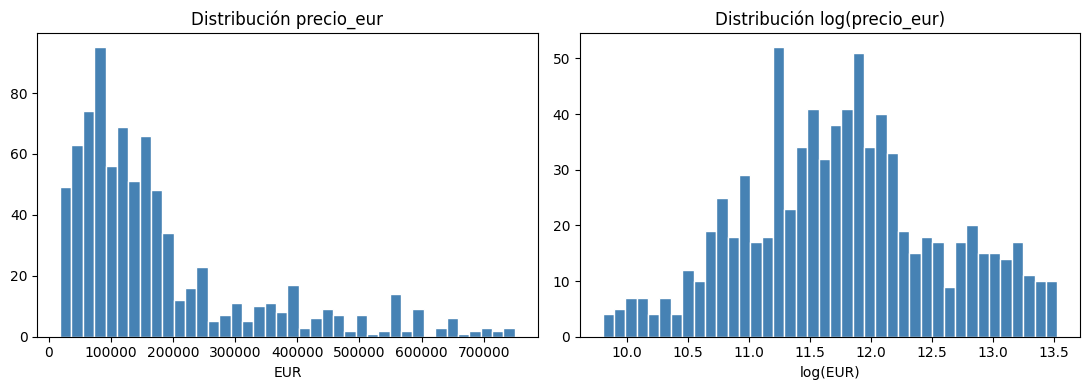

Skewness precio_eur:      1.6671
Skewness log(precio_eur): 0.0608


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df['precio_eur'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución precio_eur')
axes[0].set_xlabel('EUR')

axes[1].hist(np.log(df['precio_eur']), bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Distribución log(precio_eur)')
axes[1].set_xlabel('log(EUR)')

plt.tight_layout()
plt.show()

print(f'Skewness precio_eur:      {df["precio_eur"].skew():.4f}')
print(f'Skewness log(precio_eur): {np.log(df["precio_eur"]).skew():.4f}')

## 4. Exclusión de features con data leakage

- **`precio_m2`**: derivada directamente del target (`precio_eur / superficie_m2`). Usarla como feature introduce data leakage — el modelo aprendería a invertir la fórmula en lugar de aprender patrones reales.
- **`titulo`**: texto libre con barrio y municipio. El municipio ya está capturado en `municipio`. Procesarlo requeriría NLP fuera del alcance de este pipeline.

In [8]:
cols_excluir = ['precio_m2', 'titulo']
df = df.drop(columns=cols_excluir)

print(f'Columnas tras exclusión: {df.columns.tolist()}')

Columnas tras exclusión: ['municipio', 'precio_eur', 'superficie_m2', 'tipo_suelo', 'vendido_con_descuento', 'es_urbano_o_urbanizable']


## 5. Log-transformación del target

In [9]:
df['log_precio'] = np.log(df['precio_eur'])

print(f'Target: log_precio')
print(df['log_precio'].describe())

Target: log_precio
count    812.000000
mean      11.767592
std        0.805963
min        9.798127
25%       11.225243
50%       11.760556
75%       12.254863
max       13.527828
Name: log_precio, dtype: float64


## 6. Target encoding de `municipio`

`municipio` tiene 35 categorías con distribución muy desigual (de 1 a 133 observaciones por municipio). One-hot encoding generaría columnas casi vacías. Se aplica **target encoding**: cada municipio se sustituye por la media de `log_precio` de ese municipio calculada sobre el dataset completo.

> **Nota**: este encoding se calcula sobre todos los datos. En el notebook de ML, el target encoding debe recalcularse dentro de cada fold de cross-validation para evitar leakage.

In [10]:
target_encoding_municipio = df.groupby('municipio')['log_precio'].mean()

print('Target encoding por municipio (log_precio medio):')
print(target_encoding_municipio.sort_values(ascending=False).to_string())

Target encoding por municipio (log_precio medio):
municipio
El Astillero                 13.237120
Medio Cudeyo (Valdecilla)    12.873902
Ruiloba                      12.789685
Mogro                        12.706848
Ribamontán al Mar            12.503865
Comillas                     12.399694
Astillero                    12.389188
Santander                    12.354003
Santillana del Mar           12.115668
Villaescusa                  12.104668
Suances                      11.990109
Cabezón de la Sal            11.944577
Mazcuerras                   11.936935
Medio Cudeyo                 11.888614
Santa Cruz de Bezana         11.885144
Camargo                      11.847069
Alfoz de Lloredo             11.767190
Piélagos                     11.754592
Marina de Cudeyo             11.746078
Polanco                      11.697581
Miengo                       11.685489
Viveda                       11.660751
Reocín                       11.575193
Ribamontán al Monte          11.542253
Bare

In [11]:
df['municipio_encoded'] = df['municipio'].map(target_encoding_municipio)

print(f'Nulos en municipio_encoded: {df["municipio_encoded"].isnull().sum()}')
df = df.drop(columns=['municipio'])

Nulos en municipio_encoded: 0


## 7. One-hot encoding de `tipo_suelo`

In [12]:
dummies_suelo = pd.get_dummies(df['tipo_suelo'], prefix='tipo_suelo', drop_first=False, dtype=int)
print('Dummies creadas:')
print(dummies_suelo.sum())

df = pd.concat([df.drop(columns=['tipo_suelo']), dummies_suelo], axis=1)

Dummies creadas:
tipo_suelo_No urbanizable    122
tipo_suelo_Urbanizable       238
tipo_suelo_Urbano (solar)    452
dtype: int64


## 8. Conversión de booleanos a enteros

In [13]:
cols_bool = ['vendido_con_descuento', 'es_urbano_o_urbanizable']
df[cols_bool] = df[cols_bool].astype(int)

print('Distribución de variables binarias:')
print(df[cols_bool].sum())

Distribución de variables binarias:
vendido_con_descuento       32
es_urbano_o_urbanizable    690
dtype: int64


## 9. Dataset gold final

In [14]:
print('Columnas del gold dataset:')
print(df.columns.tolist())
print(f'\nShape final: {df.shape}')
df.describe()

Columnas del gold dataset:
['precio_eur', 'superficie_m2', 'vendido_con_descuento', 'es_urbano_o_urbanizable', 'log_precio', 'municipio_encoded', 'tipo_suelo_No urbanizable', 'tipo_suelo_Urbanizable', 'tipo_suelo_Urbano (solar)']

Shape final: (812, 9)


,precio_eur,superficie_m2,vendido_con_descuento,es_urbano_o_urbanizable,log_precio,municipio_encoded,tipo_suelo_No urbanizable,tipo_suelo_Urbanizable,tipo_suelo_Urbano (solar)
count,812.00000,812.000000,812.000000,812.000000,812.000000,812.000000,812.000000,812.000000,812.000000
mean,177880.80665,3753.624384,0.039409,0.849754,11.767592,11.767592,0.150246,0.293103,0.556650
std,153871.23429,3388.458092,0.194686,0.357533,0.805963,0.356217,0.357533,0.455466,0.497087
min,18000.00000,113.000000,0.000000,0.000000,9.798127,11.088584,0.000000,0.000000,0.000000
25%,75000.00000,1364.500000,0.000000,1.000000,11.225243,11.542253,0.000000,0.000000,0.000000
50%,128100.00000,2595.000000,0.000000,1.000000,11.760556,11.754592,0.000000,0.000000,1.000000
75%,210000.00000,4954.000000,0.000000,1.000000,12.254863,11.936935,0.000000,1.000000,1.000000
max,750000.00000,16270.000000,1.000000,1.000000,13.527828,13.237120,1.000000,1.000000,1.000000


In [15]:
print('Nulos en el gold dataset:')
print(df.isnull().sum())

Nulos en el gold dataset:
precio_eur                   0
superficie_m2                0
vendido_con_descuento        0
es_urbano_o_urbanizable      0
log_precio                   0
municipio_encoded            0
tipo_suelo_No urbanizable    0
tipo_suelo_Urbanizable       0
tipo_suelo_Urbano (solar)    0
dtype: int64


In [16]:
output_path = '../../data/gold/final_land_scraping.csv'
df.to_csv(output_path, index=False)
print(f'Gold dataset exportado a: {output_path}')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')

Gold dataset exportado a: ../../data/gold/final_land_scraping.csv
Filas: 812 | Columnas: 9
